In [1]:
import utils
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
utils.default_plt_params()

In [2]:
# data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id' # these are data with both off and on food time points, but without neuron ID labels

data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf702_with_id' # these are data with only on-food time points, but with neuron ID labels

nsm_idx = 75

uid = '2022-07-26-31-data.h5'

path_h5 = os.path.join(data_pth,uid)


In [3]:
# run this cell if this is a SWF415 dataset (without neuron ID labels, both off-food and on-food time points were recorded)

with h5py.File(path_h5, 'r') as h5f:
    data = utils.h5_to_dict(h5f)
     


In [9]:
data.keys()

dict_keys(['behavior', 'gcamp', 'timing'])

In [5]:
data['behavior'].keys()

dict_keys(['angular_velocity', 'body_angle', 'body_angle_absolute', 'body_angle_all', 'head_angle', 'nose_angle', 'nose_curling', 'pumping', 'reversal_events', 'reversal_vec', 'stage_x', 'stage_y', 'velocity', 'worm_curvature'])

In [10]:
data['gcamp'].keys()

dict_keys(['idx_nsm', 'idx_splits', 'match_org_to_skip', 'match_skip_to_org', 'trace_array', 'trace_array_original', 'traces_array_F_F20'])

In [58]:
data['gcamp']['idx_nsm']

array([ 65, 110])

In [7]:
data['timing'].keys()

dict_keys(['timestamp_confocal', 'timestamp_nir'])

In [ ]:
data['gcamp']['trace_array'].shape

In [ ]:
plt.figure()
plt.plot(data['gcamp']['traces_array_F_F20'][:,nsm_idx])
plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
plt.xlabel('time (frames)')
plt.ylabel('NSM activity (F/F20)')
plt.show()

plt.figure()
plt.plot(data['behavior']['velocity'])
plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
plt.xlabel('time (frames)')
plt.ylabel('Velocity')
plt.show()

## CURATE NSM OVER ALL DATASETS

Processing swf415_no_id dataset...
  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-01-16-01-data.h5...


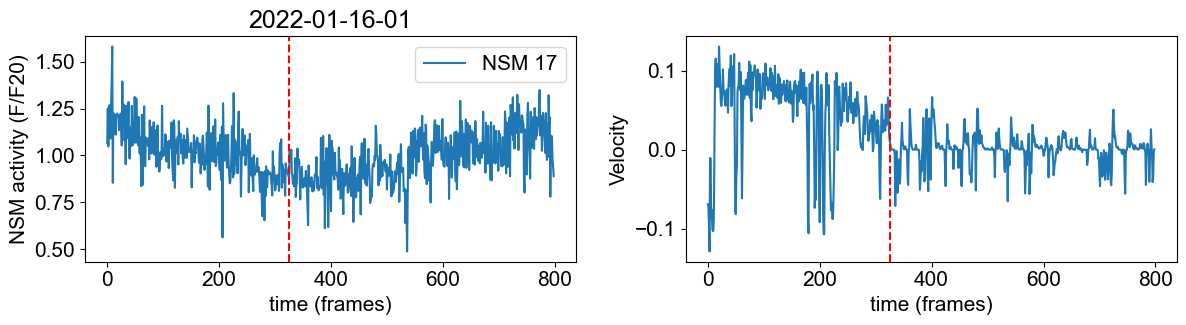

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-01-25-01-data.h5...


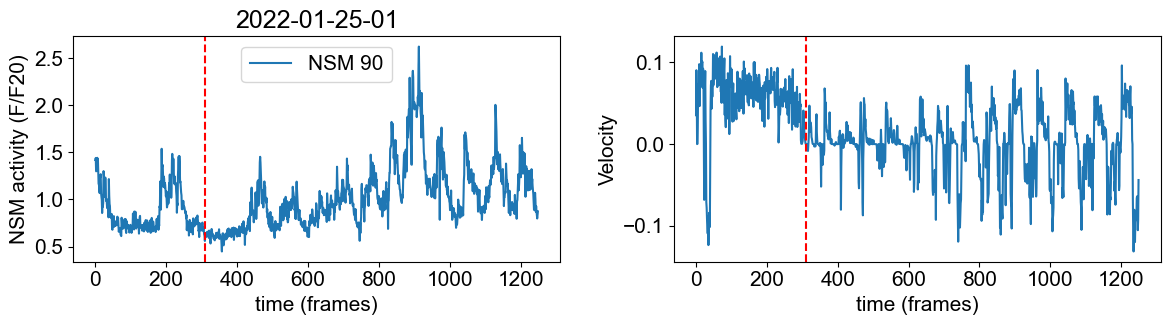

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-03-17-01-data.h5...


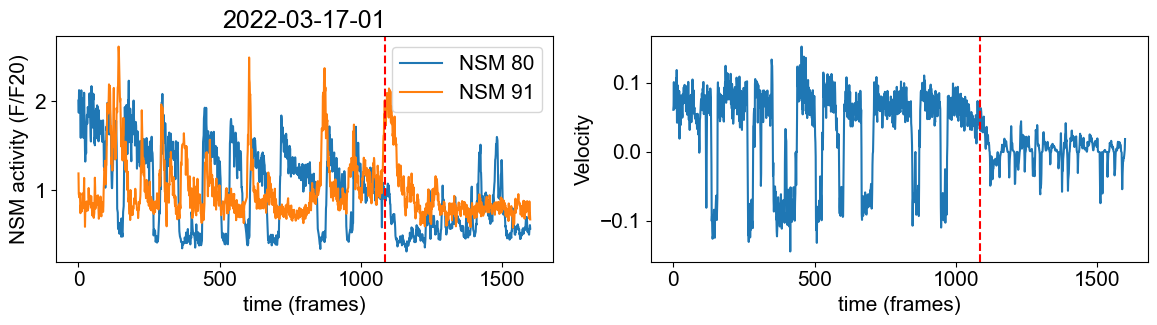

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-03-25-03-data.h5...


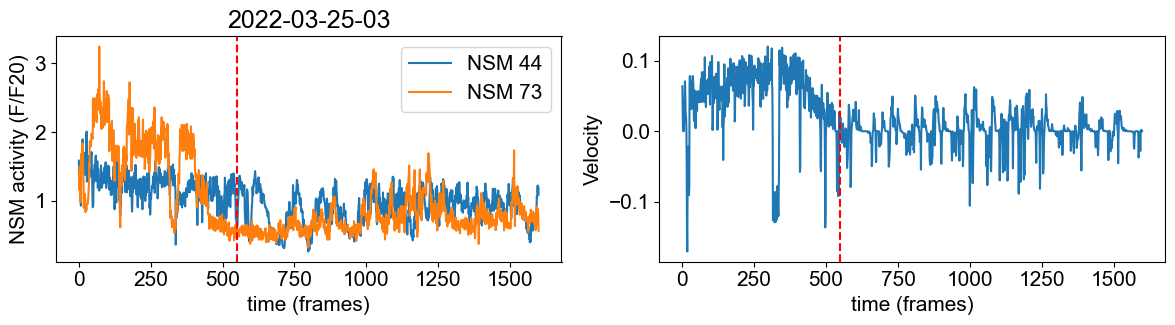

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-04-05-01-data.h5...


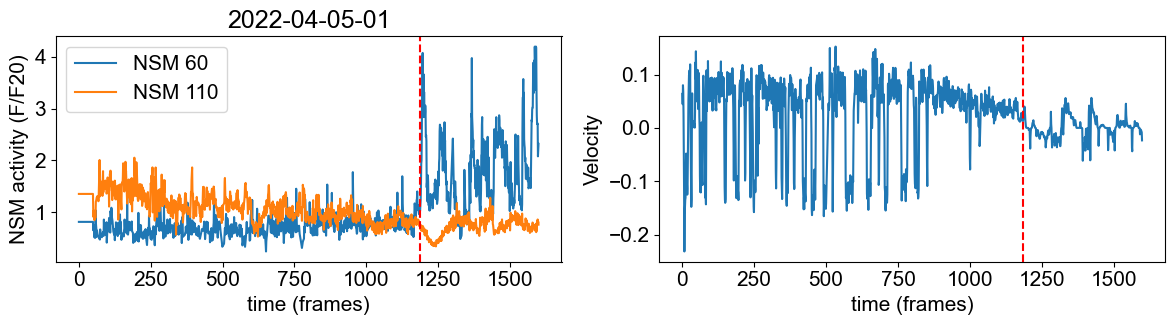

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-04-12-02-data.h5...


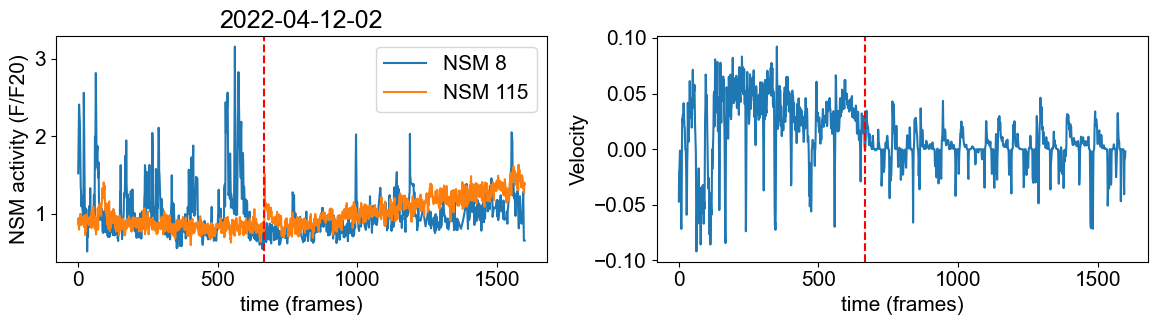

  Loading C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024\swf415_no_id\2022-05-02-01-data.h5...


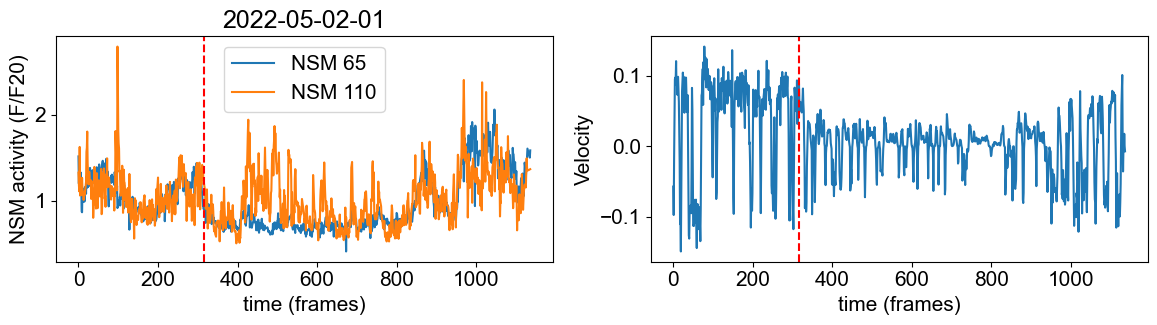

In [57]:
import utils
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
utils.default_plt_params()
import glob

data_pth = r'C:\Users\munib\POSTDOC\DATA\Dag_Nwabudike_Kang_2024'

swf_pth = ['swf415_no_id']

plt.close('all')

for swf in swf_pth:
    print(f'Processing {swf} dataset...')
    swf_dir = os.path.join(data_pth, swf)
    h5_files = glob.glob(os.path.join(swf_dir, '*.h5'))
    
    for h5_file in h5_files:
        print(f'  Loading {h5_file}...')
        with h5py.File(h5_file, 'r') as h5f:
            data = utils.h5_to_dict(h5f)

        nsm_idx = data['gcamp']['idx_nsm']
        
        plt.figure(figsize=(12, 3.5))
        
        plt.subplot(1, 2, 1)
        # if nsm_idx is a list, plot all traces
        if isinstance(nsm_idx, (list, np.ndarray)):
            for idx in nsm_idx:
                plt.plot(data['gcamp']['traces_array_F_F20'][:, idx], label=f'NSM {idx}')
            plt.legend()
        else:
            plt.plot(data['gcamp']['traces_array_F_F20'][:, nsm_idx])
        plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
        plt.xlabel('time (frames)')
        plt.ylabel('NSM activity (F/F20)')
        plt.title(f'{os.path.basename(h5_file)[:-8]}')
        
        plt.subplot(1, 2, 2)
        plt.plot(data['behavior']['velocity'])
        plt.axvline(data['timing']['time_food_encounter'], color='red', linestyle='--')
        plt.xlabel('time (frames)')
        plt.ylabel('Velocity')
        
        plt.tight_layout()
        plt.show()
